In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import rcParams
import seaborn as sns
import seaborn.objects as so
import numpy as np
from lqg import xcorr
import arviz as az

from jax import random

plt.style.use("cppp.notebook")
theme = {**sns.axes_style("ticks"), **rcParams}
so.Plot.config.theme.update(theme)

from cppp.models.multisensory import MultisensoryDelayModel, UnisensoryDelayModel
from cppp.load import preprocess_multisensory_data, load_multisensory_data


## Load data

In [2]:

df = load_multisensory_data(base_path="../data")
df.head()

print(df["participant"].unique())

Multisensory DataFrame loaded from ../data/multisensory/df_all_phases_all_participants.csv with shape: (492343, 14)
[135033060 173058413 177196795 182095555 212056115 330954011 524048600
 544725341 644801403 657093471 714671738 741917610 765738475 799755310
 802096684 879521247 891444214 910949717 918338248]


In [3]:
df.columns

Index(['participant', 'perturb', 'session', 'phase', 'trial_number', 'type',
       'vis_noise', 'cursor_offset', 'time', 'lefty_pos', 'leftx_pos',
       'righty_pos', 'rightx_pos', 'cursory_pos'],
      dtype='object')

In [4]:
for condition in df["type"].unique():
    for vis_noise in df["vis_noise"].unique():
        print(condition, vis_noise)
        data = preprocess_multisensory_data(
                        df, participant=765738475, condition=condition, vis_noise=vis_noise
                    )
        print(data.shape)

vis 1
(8, 166, 2)
vis 2
(8, 166, 2)
multi 1
(8, 166, 2)
multi 2
(8, 166, 2)
prop 1
(8, 166, 2)
prop 2
(8, 166, 2)


## Joint model

In [21]:
# participant = 765738475
participant = 212056115
seed = 7453
# participant = 802096684
models = {model_name: az.from_netcdf(
                f"../results/multisensory-mcmc-{participant}_1_2_{seed}_1000_2500_4_{model_name}.nc"
            )
            for model_name in ["optimal", "no_integration", "equal_integration"]}

# TODO: rhats

                   rank     elpd_loo     p_loo  elpd_diff        weight  \
no_integration        0 -2986.167114  4.166260   0.000000  1.000000e+00   
optimal               1 -2989.947571  4.078308   3.780457  3.084755e-13   
equal_integration     2 -3034.638062  5.710388  48.470947  0.000000e+00   

                          se        dse  warning scale  
no_integration     85.521702   0.000000    False   log  
optimal            86.481094   1.606924    False   log  
equal_integration  87.251134  11.108091    False   log  
                   rank     elpd_loo     p_loo  elpd_diff        weight  \
no_integration        0 -3085.426147  5.876892   0.000000  7.765049e-01   
optimal               1 -3088.739685  5.877167   3.313538  2.286686e-15   
equal_integration     2 -3128.851685  7.211975  43.425537  2.234951e-01   

                           se        dse  warning scale  
no_integration      99.425469   0.000000    False   log  
optimal            100.307878   1.755442    False   lo

/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-proprioception/.venv/lib/python3.10/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
/scratch/ds2181/cpp-propri

                   rank     elpd_loo      p_loo  elpd_diff        weight  \
optimal               0 -3006.943085  33.302032   0.000000  3.956890e-01   
no_integration        1 -3009.949585  34.335083   3.006500  5.495730e-16   
equal_integration     2 -3012.941772  34.531616   5.998688  6.043110e-01   

                          se        dse  warning scale  
optimal            71.642152   0.000000     True   log  
no_integration     72.225865   1.134847     True   log  
equal_integration  72.689735  12.619967     True   log  
                   rank     elpd_loo     p_loo  elpd_diff    weight  \
optimal               0 -2373.068848  4.103363   0.000000  0.723769   
no_integration        1 -2373.301880  4.365417   0.233032  0.000000   
equal_integration     2 -2386.802338  8.254791  13.733490  0.276231   

                          se        dse  warning scale  
optimal            77.314825   0.000000    False   log  
no_integration     78.073565   0.858368    False   log  
equal_integ

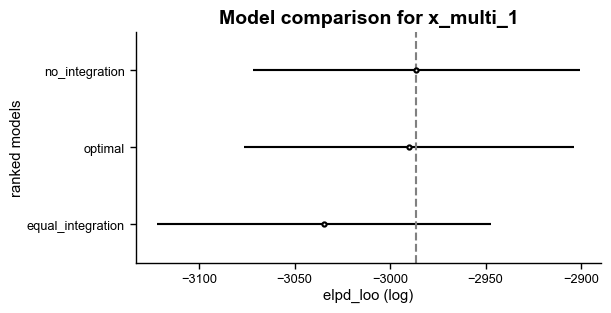

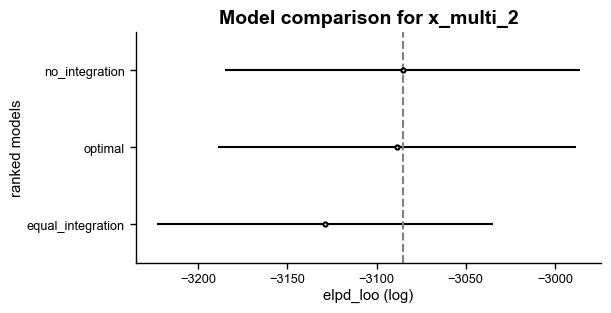

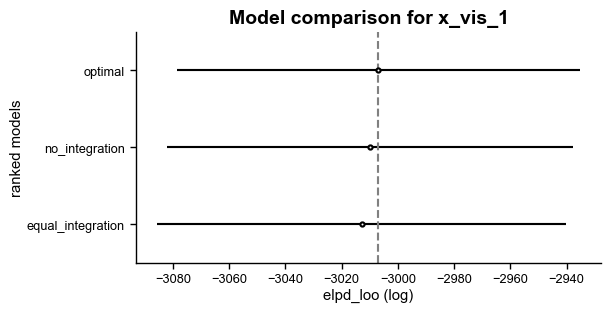

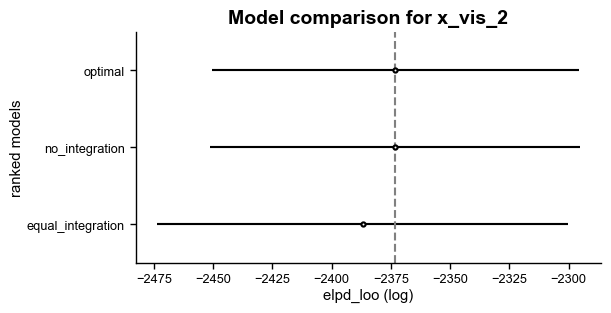

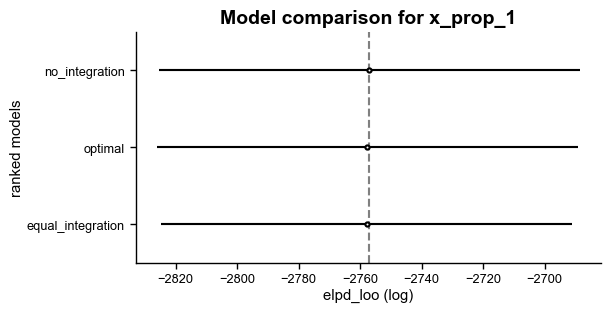

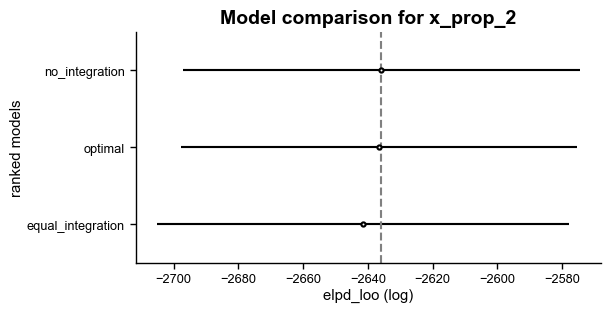

In [22]:
for var_name in ["x_multi_1", "x_multi_2", "x_vis_1", "x_vis_2", "x_prop_1", "x_prop_2"]:

    comp_df = az.compare(models, var_name=var_name)
    print(comp_df)
    axes = az.plot_compare(comp_df=comp_df)
    axes.set_title(f"Model comparison for {var_name}")

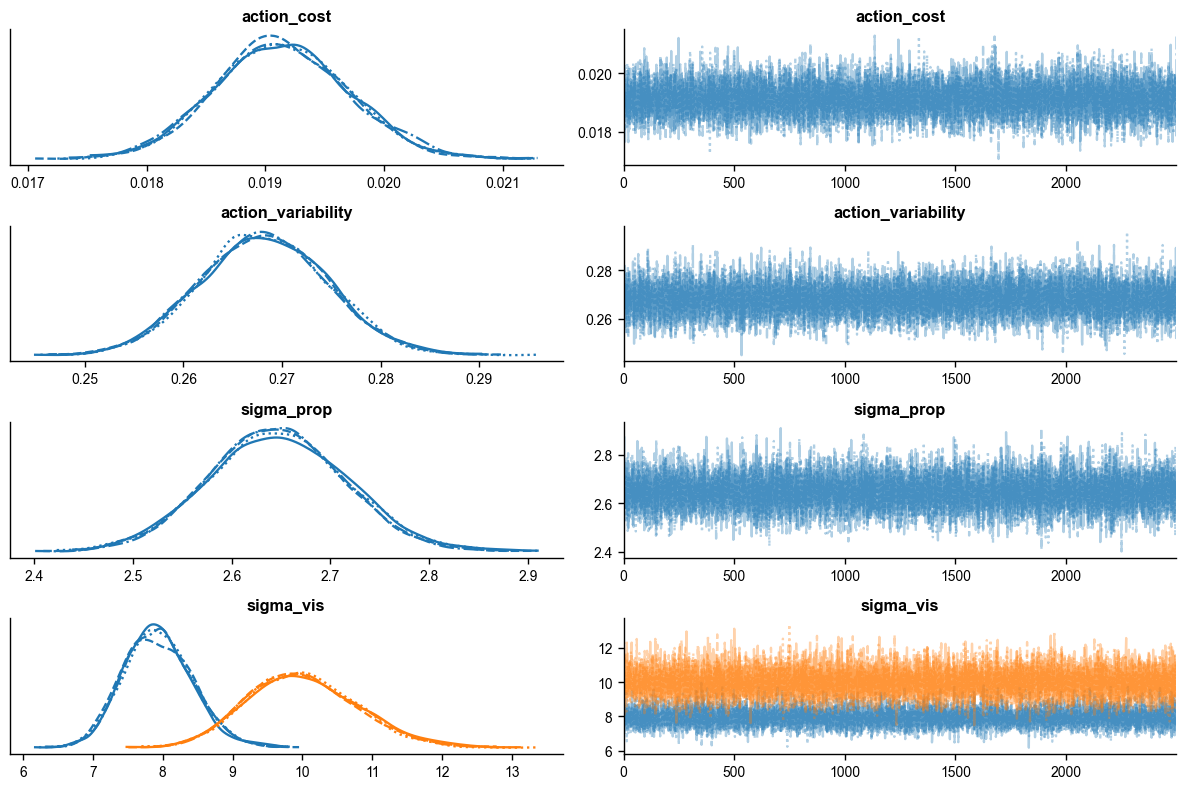

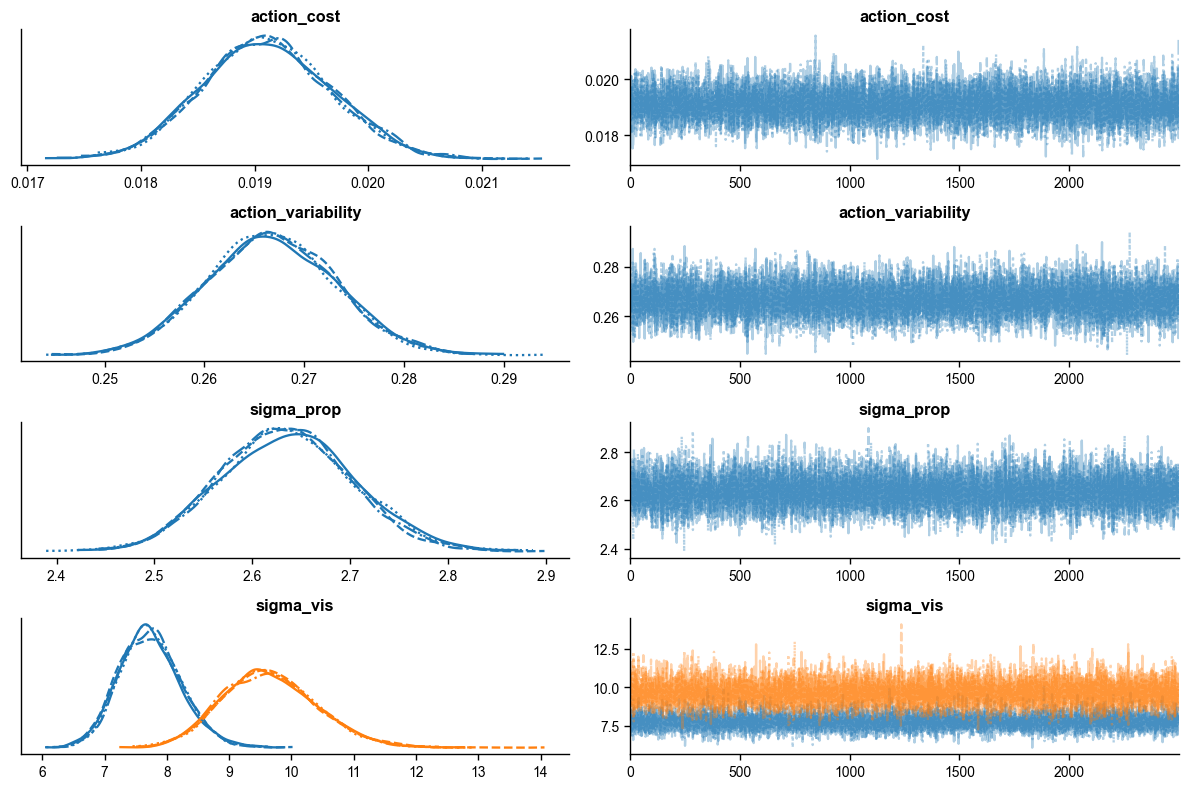

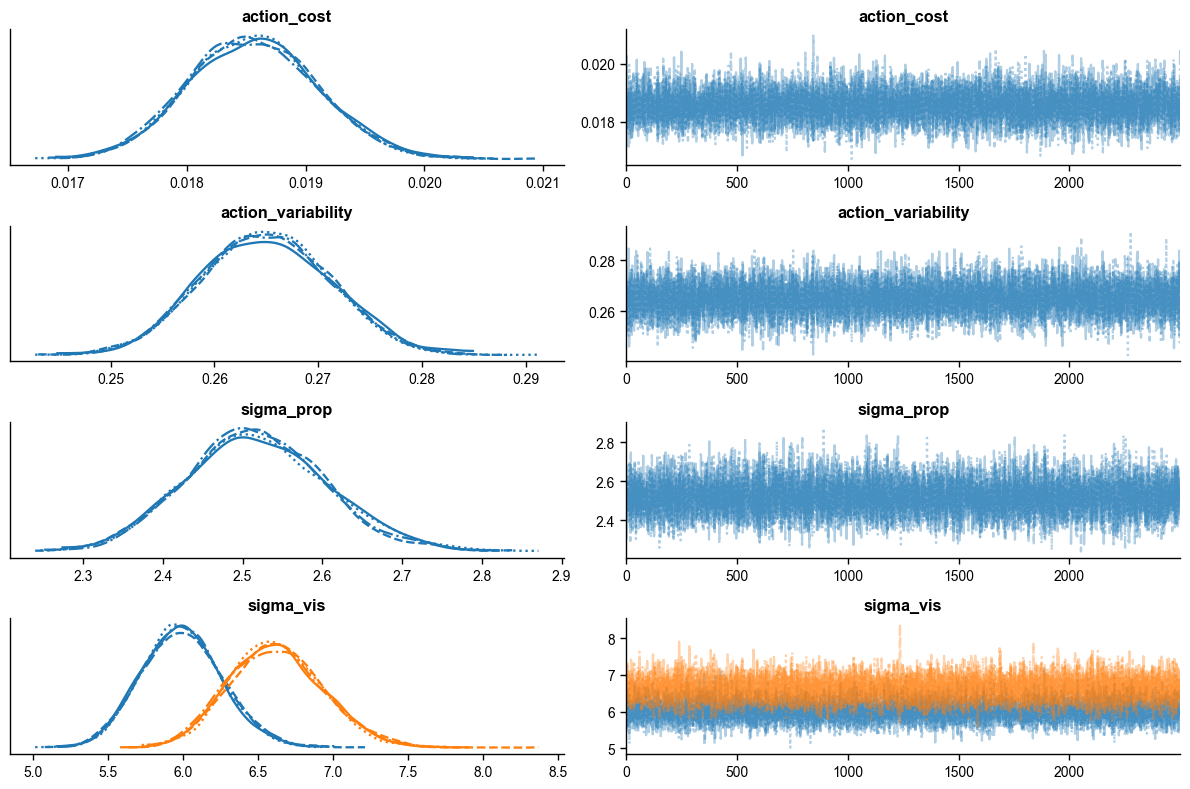

In [23]:
for name, model in models.items():
    az.plot_trace(model)
    plt.tight_layout()

Condition: multi, Vis Noise: 1
{'action_cost': 0.019, 'action_variability': 0.268, 'sigma_prop': 2.646, 'sigma_vis[0]': 7.933, 'sigma_vis[1]': 10.005}
(4, 2500, 101)
Condition: multi, Vis Noise: 2
{'action_cost': 0.019, 'action_variability': 0.268, 'sigma_prop': 2.646, 'sigma_vis[0]': 7.933, 'sigma_vis[1]': 10.005}
(4, 2500, 101)
Condition: vis, Vis Noise: 1
{'action_cost': 0.019, 'action_variability': 0.268, 'sigma_prop': 2.646, 'sigma_vis[0]': 7.933, 'sigma_vis[1]': 10.005}
(4, 2500, 101)
Condition: vis, Vis Noise: 2
{'action_cost': 0.019, 'action_variability': 0.268, 'sigma_prop': 2.646, 'sigma_vis[0]': 7.933, 'sigma_vis[1]': 10.005}
(4, 2500, 101)
Condition: prop, Vis Noise: 1
{'action_cost': 0.019, 'action_variability': 0.268, 'sigma_prop': 2.646, 'sigma_vis[0]': 7.933, 'sigma_vis[1]': 10.005}
(4, 2500, 101)
Condition: prop, Vis Noise: 2
{'action_cost': 0.019, 'action_variability': 0.268, 'sigma_prop': 2.646, 'sigma_vis[0]': 7.933, 'sigma_vis[1]': 10.005}
(4, 2500, 101)
Condition:

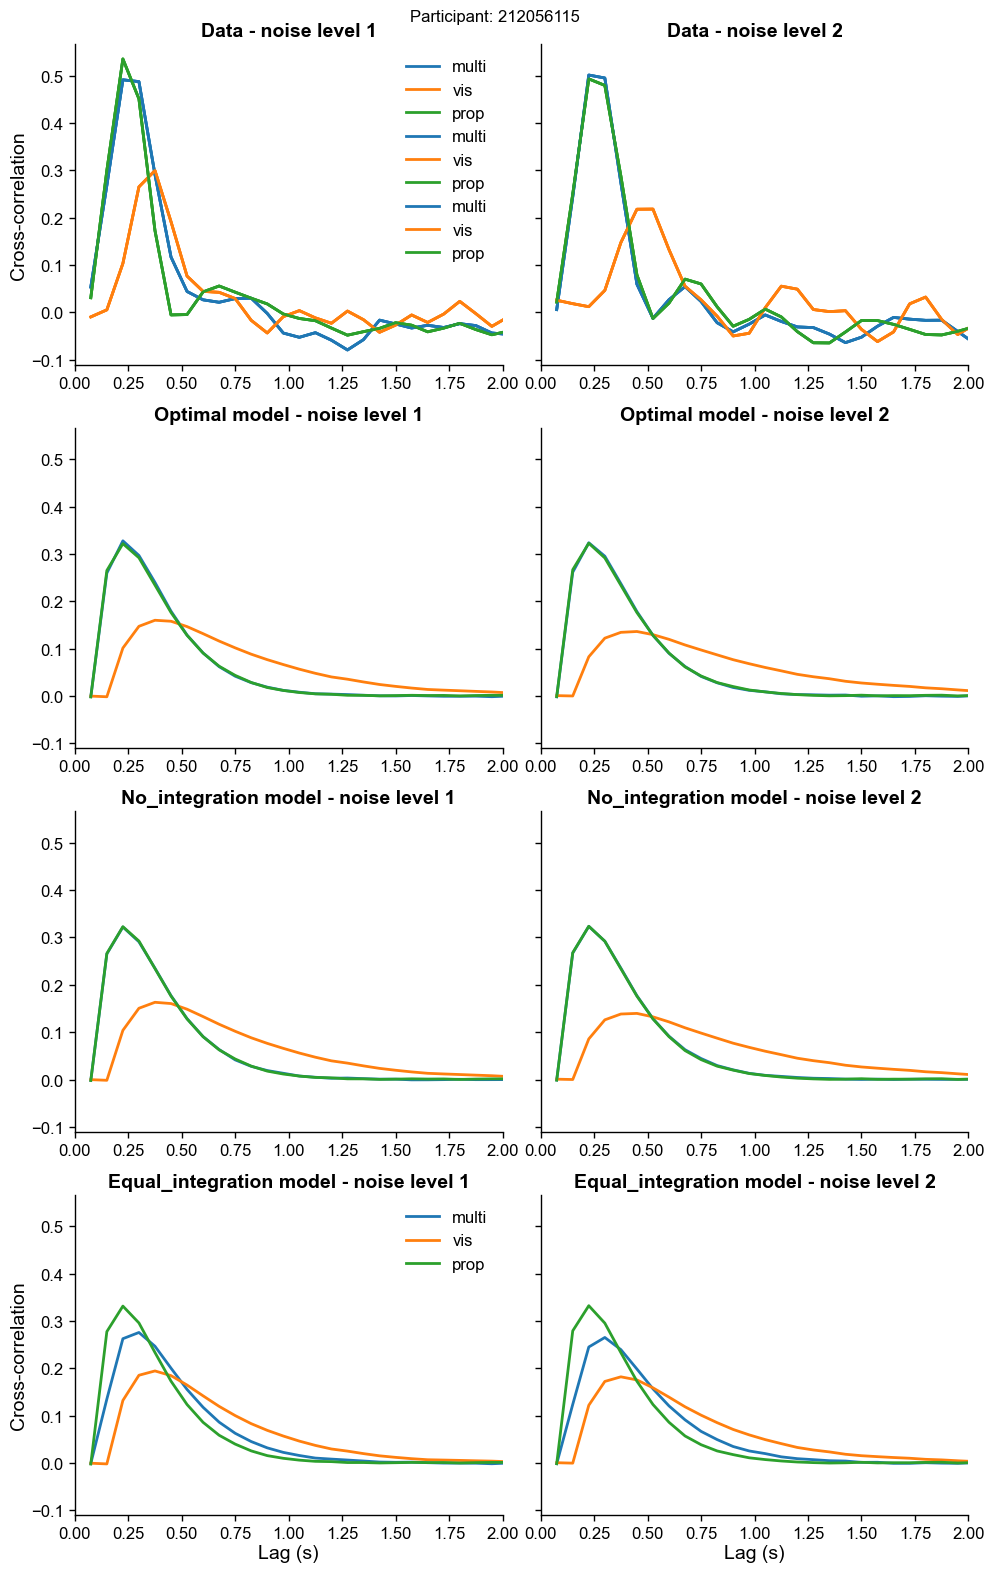

In [25]:
import jax.numpy as jnp

delays = {"prop": 1, "vis": 2}

f, ax = plt.subplots(4, 2, figsize=(10, 16), sharey=True)

for k, (model_name, model) in enumerate(models.items()):
    summary = az.summary(model)
    # get posterior mean
    posterior_mean = summary["mean"].to_dict()
    for i, condition in enumerate(["multi", "vis", "prop"]):

        for j, vis_noise in enumerate([1, 2]):
            # preprocess the data for this participant, condition, and noise level
            data = preprocess_multisensory_data(
                    df, participant=participant, condition=condition, vis_noise=vis_noise
                )

            
            print(f"Condition: {condition}, Vis Noise: {vis_noise}")
            print(posterior_mean)

            # # create model with posterior mean parameters (note that we have to rename the sigmas parameters for the multisensory model)
            # if condition == "multi":
            #     if model_name == "optimal":
            #         model = MultisensoryDelayModel(
            #             process_noise=1.2,
            #             sigmas=[posterior_mean["sigma_prop"], posterior_mean[f"sigma_vis[{vis_noise - 1}]"]],
            #             action_variability=posterior_mean["action_variability"],
            #             action_cost=posterior_mean["action_cost"],
            #             delays=[delays["prop"], delays["vis"]],
            #             dt=0.075,
            #             T=data.shape[1],
            #         )
            #     elif model_name == "no_integration":
            #         model = MultisensoryDelayModel(
            #             process_noise=1.2,
            #             sigmas=[posterior_mean["sigma_prop"]],
            #             action_variability=posterior_mean["action_variability"],
            #             action_cost=posterior_mean["action_cost"],
            #             delays=[delays["prop"]],
            #             dt=0.075,
            #             T=data.shape[1],
            #         )
            #     elif model_name == "equal_integration":
            #         sigma = jnp.sqrt((posterior_mean["sigma_prop"] ** 2 + posterior_mean[f"sigma_vis[{vis_noise - 1}]"] ** 2) / 2)
            #         model = MultisensoryDelayModel(
            #             process_noise=1.2,
            #             sigmas=[sigma, sigma],
            #             action_variability=posterior_mean["action_variability"],
            #             action_cost=posterior_mean["action_cost"],
            #             delays=[delays["prop"], delays["vis"]],
            #             dt=0.075,
            #             T=data.shape[1],
            #         )
            # else:
            #     delay = delays[condition]
            #     model = UnisensoryDelayModel(
            #         process_noise=1.2,
            #         sigma=posterior_mean[f"sigma_{condition}"] if condition == "prop" else posterior_mean[f"sigma_vis[{vis_noise - 1}]"],
            #         action_variability=posterior_mean["action_variability"],
            #         action_cost=posterior_mean["action_cost"],
            #         delay=delay,
            #         dt=0.075,
            #         T=data.shape[1],
            #     )

            # # TODO: generate prediction for multisensory condition from unisensory model fits

            # # simulate data from the model and compute cross-correlation of velocities for both the simulated data and the real data
            # sim_data = model.simulate(rng_key=random.PRNGKey(0), n=100)

            sim_data = model.posterior_predictive[
            f"x_{condition}_{vis_noise}"
        ]# .mean(axis=(0, 1))
            sim_vels = np.diff(sim_data, axis=-2)
            lags, sim_correls = xcorr(sim_vels[..., 1], sim_vels[..., 0], maxlags=50)
            print(sim_correls.shape)

            
            vels = np.diff(data, axis=1)
            lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

            # plot the cross-correlations for the real data and the simulated data
            ax[0, j].plot(
                lags[51:] * 0.075, correls.mean(axis=0)[51:], label=f"{condition}", color=f"C{i}"
            )
            ax[k+1, j].plot(
                lags[51:] * 0.075, sim_correls.mean(axis=(0, 1))[51:], label=f"{condition}", color=f"C{i}"
            )

            ax[0, j].set_xlim(0, 2)
            ax[k+1, j].set_xlim(0, 2)

            ax[0, j].set_title(f"Data - noise level {vis_noise}")
            ax[k+1, j].set_title(f"{model_name.capitalize()} model - noise level {vis_noise}")

ax[k+1, 0].set_xlabel("Lag (s)")
ax[k+1, 1].set_xlabel("Lag (s)")
ax[0, 0].set_ylabel("Cross-correlation")
ax[k+1, 0].set_ylabel("Cross-correlation")

ax[0, 0].legend()
ax[k+1, 0].legend()
f.suptitle(f"Participant: {participant}")
f.tight_layout()

In [22]:
k = 0
seed = 7453
participant = 135033060

model = az.from_netcdf(
                f"../results/multisensory-mcmc-{participant}_1_2_{seed}_500_1000_4_equal_integration.nc"
            )

model.posterior_predictive

<xarray.Dataset> Size: 78MB
Dimensions:          (chain: 4, draw: 1000, x_multi_1_dim_0: 166,
                      x_multi_1_dim_1: 6, x_multi_2_dim_0: 166,
                      x_multi_2_dim_1: 6, x_prop_1_dim_0: 166,
                      x_prop_1_dim_1: 4, x_prop_2_dim_0: 166,
                      x_prop_2_dim_1: 4, x_vis_1_dim_0: 98, x_vis_1_dim_1: 6,
                      x_vis_2_dim_0: 166, x_vis_2_dim_1: 6)
Coordinates: (12/14)
  * chain            (chain) int64 32B 0 1 2 3
  * draw             (draw) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * x_multi_1_dim_0  (x_multi_1_dim_0) int64 1kB 0 1 2 3 4 ... 162 163 164 165
  * x_multi_1_dim_1  (x_multi_1_dim_1) int64 48B 0 1 2 3 4 5
  * x_multi_2_dim_0  (x_multi_2_dim_0) int64 1kB 0 1 2 3 4 ... 162 163 164 165
  * x_multi_2_dim_1  (x_multi_2_dim_1) int64 48B 0 1 2 3 4 5
    ...               ...
  * x_prop_2_dim_0   (x_prop_2_dim_0) int64 1kB 0 1 2 3 4 ... 162 163 164 165
  * x_prop_2_dim_1   (x_prop_2_dim_1) int64 32B 0 1 2 3
  * x_vis_1_dim_0    (x_vis_1_dim_0) int64 784B 0 1 2 3 4 5 ... 93 94 95 96 97
  * x_vis_1_dim_1    (x_vis_1_dim_1) int64 48B 0 1 2 3 4 5
  * x_vis_2_dim_0    (x_vis_2_dim_0) int64 1kB 0 1 2 3 4 ... 161 162 163 164 165
  * x_vis_2_dim_1    (x_vis_2_dim_1) int64 48B 0 1 2 3 4 5
Data variables:
    x_multi_1        (chain, draw, x_multi_1_dim_0, x_multi_1_dim_1) float32 16MB ...
    x_multi_2        (chain, draw, x_multi_2_dim_0, x_multi_2_dim_1) float32 16MB ...
    x_prop_1         (chain, draw, x_prop_1_dim_0, x_prop_1_dim_1) float32 11MB ...
    x_prop_2         (chain, draw, x_prop_2_dim_0, x_prop_2_dim_1) float32 11MB ...
    x_vis_1          (chain, draw, x_vis_1_dim_0, x_vis_1_dim_1) float32 9MB ...
    x_vis_2          (chain, draw, x_vis_2_dim_0, x_vis_2_dim_1) float32 16MB ...
Attributes:
    created_at:                 2026-03-23T16:32:06.770508+00:00
    arviz_version:              0.22.0
    inference_library:          numpyro
    inference_library_version:  0.18.0

Simulating model: equal_integration
(4, 1000, 101)
(101,)
(4, 1000, 101)
(101,)
(4, 1000, 101)
(101,)
(4, 1000, 101)
(101,)
(4, 1000, 101)
(101,)
(4, 1000, 101)
(101,)


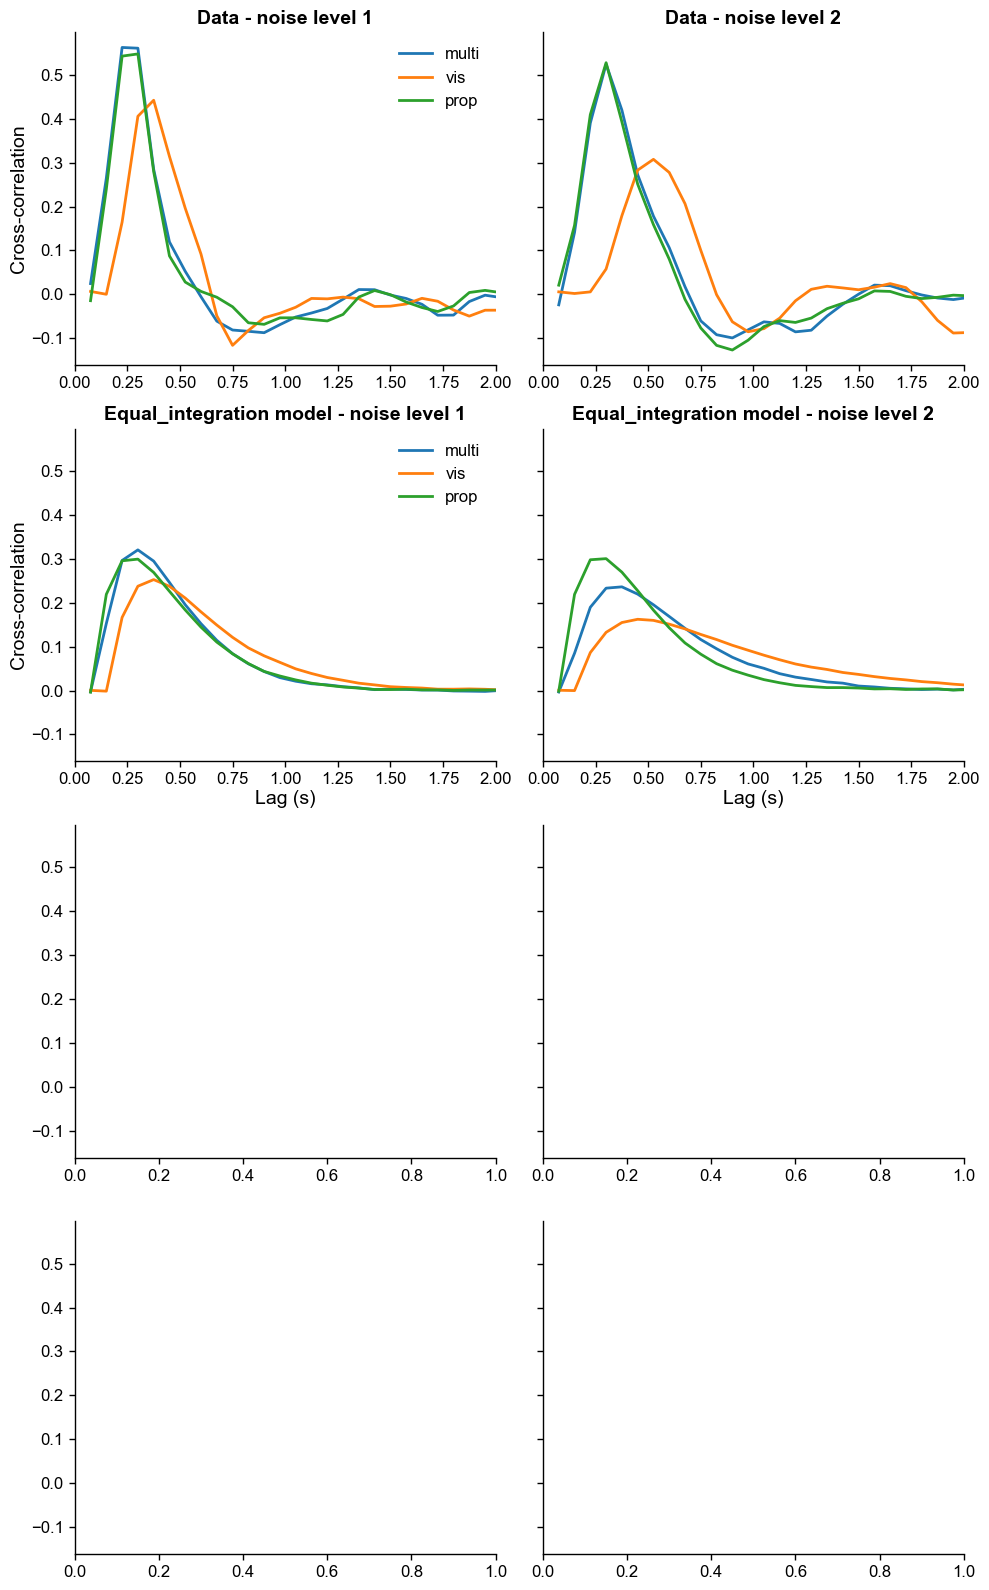

In [30]:

# print(model.log_likelihood["x_multi_1"].shape)
print(f"Simulating model: {model_name}")
# print(model.posterior)

summary = az.summary(model)
# get posterior mean
posterior_mean = summary["mean"].to_dict()

f, ax = plt.subplots(4, 2, figsize=(10, 16), sharey=True)

for i, condition in enumerate(["multi", "vis", "prop"]):

    for j, vis_noise in enumerate([1, 2]):
        # preprocess the data for this participant, condition, and noise level
        data = preprocess_multisensory_data(
                    df, participant=participant, condition=condition, vis_noise=vis_noise
            )
        
        sim_data = model.posterior_predictive[
            f"x_{condition}_{vis_noise}"
        ]# .mean(axis=(0, 1))
        

        sim_vels = np.diff(sim_data, axis=-2)
        lags, sim_correls = xcorr(
            sim_vels[..., 1], sim_vels[..., 0], maxlags=50
        )

        print(sim_correls.shape)

        vels = np.diff(data, axis=1)
        lags, correls = xcorr(vels[:, :, 1], vels[:, :, 0], maxlags=50)

        print(lags.shape)

        # plot the cross-correlations for the real data and the simulated data
        if (
            k == 0
        ):  # only plot the real data for the first model (since they are all the same)
            ax[0, j].plot(
                lags[51:] * 0.075,
                correls.mean(axis=0)[51:],
                label=f"{condition}",
                color=f"C{i}",
            )
        ax[k + 1, j].plot(
            lags[51:] * 0.075,
            sim_correls.mean(axis=(0, 1))[51:],
            label=f"{condition}",
            color=f"C{i}",
        )

        ax[0, j].set_xlim(0, 2)
        ax[k + 1, j].set_xlim(0, 2)

        ax[0, j].set_title(f"Data - noise level {vis_noise}")
        ax[k + 1, j].set_title(
            f"{model_name.capitalize()} model - noise level {vis_noise}"
        )

    ax[k + 1, 0].set_xlabel("Lag (s)")
    ax[k + 1, 1].set_xlabel("Lag (s)")
    ax[0, 0].set_ylabel("Cross-correlation")
    ax[k + 1, 0].set_ylabel("Cross-correlation")

    ax[0, 0].legend()
    ax[k + 1, 0].legend()
    f.tight_layout()

## Simulate offset phase

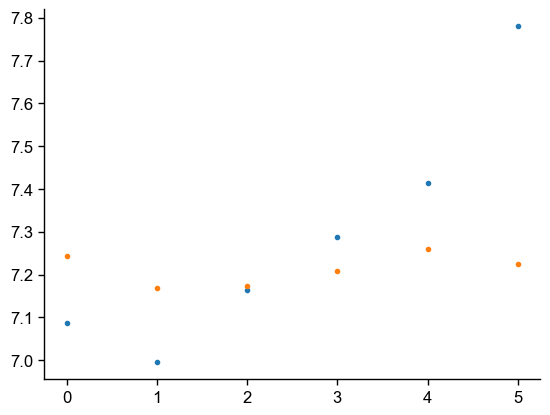

In [31]:
from jax import random
import jax.numpy as jnp

from cppp.models.multisensory import BiasMultisensoryDelayModel

summary = az.summary(models["optimal"])
# get posterior mean
posterior_mean = summary["mean"].to_dict()

key = random.PRNGKey(0)
for vis_noise in [1, 2]:
    for bias in [0, 1, 2, 3, 4, 5]:

        model = BiasMultisensoryDelayModel(
            process_noise=1.2,
            sigmas=[
                posterior_mean["sigma_prop"],
                posterior_mean[f"sigma_vis[{vis_noise - 1}]"],
            ],
            action_variability=posterior_mean["action_variability"],
            action_cost=posterior_mean["action_cost"],
            delays=[delays["prop"], delays["vis"]],
            dt=0.075,
            T=1000,
        )

        key, subkey = random.split(key)
        x = model.simulate(
            rng_key=subkey,
            n=250,
            x0=jnp.array([0.0, 0.0, bias] + [0.0] * 6),
        )
        error = jnp.mean((x[..., 1] - x[..., 0]) ** 2)

        plt.scatter(bias, error, color="C0" if vis_noise == 1 else "C1")
        # plt.axhline(0, color="black", linestyle="--")